# Building Footprint Segmentation

Binary building vs background segmentation on the Inria Aerial Image Labeling Dataset. The pipeline uses a spatial train/eval split (no leakage), a U-Net, IoU/Dice scores, and visual checks on Vienna.

**Workflow**
1. Setup (imports, config, seed, device)
2. Data acquisition and inspection
3. Patching
4. Spatial train/evaluation split
5. Transforms and DataLoaders
6. Model (U-Net / CNN encoder-decoder)
7. Loss and metrics
8. Training and validation
9. Curves and quantitative results
10. Visual error analysis
11. Optional hybrid CNN-ViT (if time allows)
12. Conclusions


## 1. Setup

### Imports

Load the libraries used across the notebook.


In [1]:
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm  # text bar

# GeoTIFF-friendly reader when available; Pillow remains as fallback
try:
    import tifffile
except ImportError:
    tifffile = None


### Configuration, seed, and device

Set the run settings in one place, fix the random seed so results are repeatable, and pick GPU when it is available.


In [2]:
# Paths (relative to this notebook's folder)
PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

# Training defaults
SEED = 42
PATCH_SIZE = 256
BATCH_SIZE = 4
LR = 0.001
EPOCHS = 10
NUM_WORKERS = 0  # safer default on Windows / local CPU

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")  # Apple Silicon (M1/M2/...)
else:
    DEVICE = torch.device("cpu")

def set_seed(seed: int = 42) -> None:
    """Seed Python, NumPy, and PyTorch so runs are easier to repeat."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(SEED)

print(f"Project dir : {PROJECT_DIR}")
print(f"Device      : {DEVICE}")
print(f"Seed        : {SEED}")
print(f"Patch size  : {PATCH_SIZE} | batch={BATCH_SIZE} | lr={LR} | epochs={EPOCHS}")


Project dir : C:\Users\Ibuchi Basil\data-science\bike-share\footprint-segmentation
Device      : cpu
Seed        : 42
Patch size  : 256 | batch=4 | lr=0.001 | epochs=10


## 2. Data acquisition and inspection

Load the Inria tiles already on disk under `data/raw/`, then continue with inspection before patching.


### 2.1 Data source

| Item | Detail |
|------|--------|
| Source | Inria Aerial Image Labeling Dataset |
| Page | https://project.inria.fr/aerialimagelabeling/ |
| Task | Building vs background (binary segmentation) |
| Tile size | 5000 × 5000 RGB @ 0.3 m |
| Cities | Austin, Vienna, Chicago, Kitsap, Tyrol |
| Local path | `data/raw/NEW2-AerialImageDataset/AerialImageDataset/` |


### 2.2 Local data path

The Inria files are not stored in this repo. Download and extract them so the folder layout matches `DATASET_ROOT` below (`train/images`, `train/gt`, `test/images`).


In [3]:
DATASET_ROOT = RAW_DIR / "NEW2-AerialImageDataset" / "AerialImageDataset"

TRAIN_IMAGES_DIR = DATASET_ROOT / "train" / "images"
TRAIN_GT_DIR = DATASET_ROOT / "train" / "gt"
TEST_IMAGES_DIR = DATASET_ROOT / "test" / "images"

for label, path in [
    ("train images", TRAIN_IMAGES_DIR),
    ("train gt", TRAIN_GT_DIR),
    ("test images", TEST_IMAGES_DIR),
]:
    print(f"{label:13} : {path}  | exists={path.is_dir()}")


train images  : C:\Users\Ibuchi Basil\data-science\bike-share\footprint-segmentation\data\raw\NEW2-AerialImageDataset\AerialImageDataset\train\images  | exists=True
train gt      : C:\Users\Ibuchi Basil\data-science\bike-share\footprint-segmentation\data\raw\NEW2-AerialImageDataset\AerialImageDataset\train\gt  | exists=True
test images   : C:\Users\Ibuchi Basil\data-science\bike-share\footprint-segmentation\data\raw\NEW2-AerialImageDataset\AerialImageDataset\test\images  | exists=True


### 2.3 Inventory

Count train image/mask pairs, list cities from the filenames, and check for unmatched names.


In [4]:
def tif_stems(folder: Path):
    return {p.stem for p in folder.glob("*.tif")} | {p.stem for p in folder.glob("*.tiff")}


def city_from_stem(stem: str) -> str:
    return "".join(ch for ch in stem if ch.isalpha()).lower()

train_image_stems = tif_stems(TRAIN_IMAGES_DIR)
train_gt_stems = tif_stems(TRAIN_GT_DIR)
test_image_stems = tif_stems(TEST_IMAGES_DIR)

paired_stems = sorted(train_image_stems & train_gt_stems)
only_images = sorted(train_image_stems - train_gt_stems)
only_masks = sorted(train_gt_stems - train_image_stems)
cities = sorted({city_from_stem(s) for s in paired_stems})

print(f"Train images : {len(train_image_stems)}")
print(f"Train gt     : {len(train_gt_stems)}")
print(f"Paired train : {len(paired_stems)}")
print(f"Test images  : {len(test_image_stems)}")
print(f"Cities       : {cities}")
print(f"Unmatched images : {len(only_images)}")
print(f"Unmatched masks  : {len(only_masks)}")
if paired_stems:
    print(f"Examples     : {paired_stems[:5]}")


Train images : 180
Train gt     : 180
Paired train : 180
Test images  : 180
Cities       : ['austin', 'chicago', 'kitsap', 'tyrolw', 'vienna']
Unmatched images : 0
Unmatched masks  : 0
Examples     : ['austin1', 'austin10', 'austin11', 'austin12', 'austin13']


### 2.4 Inspect a sample tile

Load one paired train tile and its mask, check shape and mask values, then plot a cropped aerial view, the mask, and a simple overlay.


Sample      : austin1
Image shape : (5000, 5000, 3) | dtype=uint8
Mask shape  : (5000, 5000) | dtype=uint8
Mask values : [  0 255]
Building %  : 14.76%


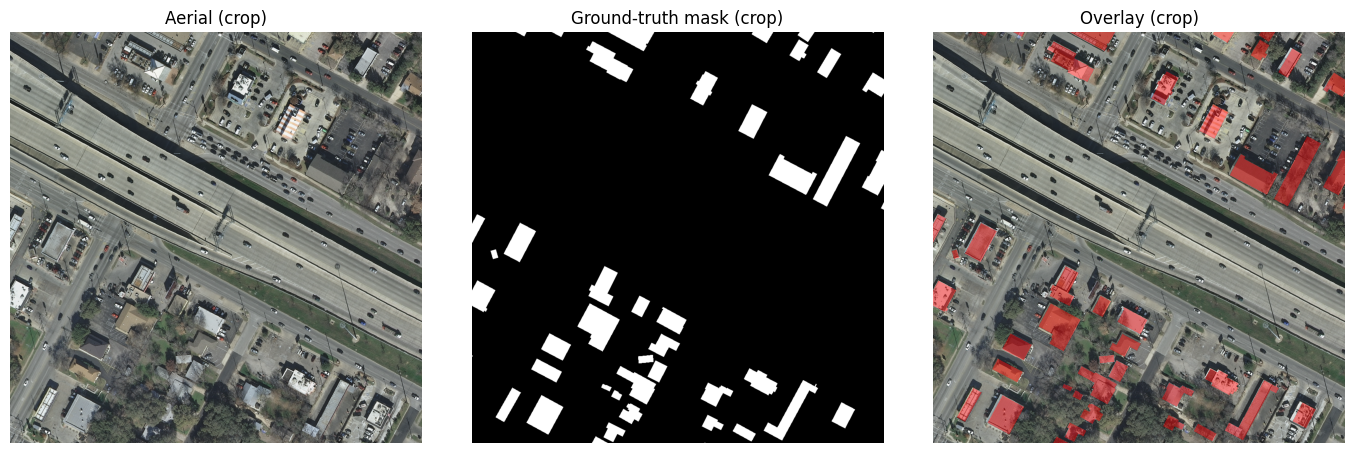

In [5]:
def resolve_tif(folder: Path, stem: str) -> Path:
    for ext in (".tif", ".tiff", ".TIF", ".TIFF"):
        path = folder / f"{stem}{ext}"
        if path.exists():
            return path
    raise FileNotFoundError(f"No TIFF for '{stem}' in {folder}")


def read_array(path: Path) -> np.ndarray:
    if tifffile is not None:
        return tifffile.imread(path)
    return np.array(Image.open(path))


sample_stem = paired_stems[0]
image = read_array(resolve_tif(TRAIN_IMAGES_DIR, sample_stem))
mask = read_array(resolve_tif(TRAIN_GT_DIR, sample_stem))
if mask.ndim == 3:
    mask = mask[..., 0]

print(f"Sample      : {sample_stem}")
print(f"Image shape : {image.shape} | dtype={image.dtype}")
print(f"Mask shape  : {mask.shape} | dtype={mask.dtype}")
print(f"Mask values : {np.unique(mask)}")
print(f"Building %  : {(mask == 255).mean():.2%}")

preview = 1024 #1024 crop so the full 5000×5000 isn’t heavy to display
img_prev = image[:preview, :preview]
mask_prev = mask[:preview, :preview]
building = mask_prev == 255

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(img_prev.astype(np.uint8, copy=False))
axes[0].set_title("Aerial (crop)")
axes[1].imshow(mask_prev, cmap="gray")
axes[1].set_title("Ground-truth mask (crop)")
axes[2].imshow(img_prev.astype(np.uint8, copy=False))
axes[2].imshow(np.ma.masked_where(~building, building), cmap="autumn", alpha=0.45)
axes[2].set_title("Overlay (crop)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


### 2.5 Acquisition summary

- Source: Inria Aerial Image Labeling Dataset under `data/raw/NEW2-AerialImageDataset/AerialImageDataset/`
- Train: 180 aerial tiles paired with 180 `gt` masks (255 = building, 0 = background)
- Test: 180 aerial tiles, no public masks
- Cities present: austin, chicago, kitsap, tyrol, vienna
- Sample check: tile shape is 5000 × 5000; buildings are a small share of pixels (class imbalance)


## 3. Patching

Cut each 5000 × 5000 train tile and its matching mask into smaller aligned patches so the data fits local training.

### 3.1 Why patch

A full Inria tile is too large to pass through a segmentation CNN in one step on this machine. Patching keeps the original resolution inside each window, pairs every image crop with the same crop on the `gt` mask, and turns each tile into many training examples. The trade-off is less whole-tile context per sample; building edges that fall on patch borders can be split across patches.


### 3.2 Patch settings

Use the configured patch size, a matching stride (non-overlapping crops), and write patches under `data/processed/`.


In [6]:
STRIDE = PATCH_SIZE  # non-overlapping patches

PATCH_DIR = PROCESSED_DIR / "patches"
PATCH_IMAGES_DIR = PATCH_DIR / "images"
PATCH_MASKS_DIR = PATCH_DIR / "masks"

PATCH_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
PATCH_MASKS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Patch size : {PATCH_SIZE} × {PATCH_SIZE}")
print(f"Stride     : {STRIDE}")
print(f"Images out : {PATCH_IMAGES_DIR}")
print(f"Masks out  : {PATCH_MASKS_DIR}")


Patch size : 256 × 256
Stride     : 256
Images out : C:\Users\Ibuchi Basil\data-science\bike-share\footprint-segmentation\data\processed\patches\images
Masks out  : C:\Users\Ibuchi Basil\data-science\bike-share\footprint-segmentation\data\processed\patches\masks


### 3.3 Build patches

Slide a 256 × 256 window across each paired train tile and mask (same crop on both), and save the patches under `data/processed/patches/`. Only full windows are kept; leftover edge strips smaller than the patch size are skipped.


In [7]:
def save_patch(arr: np.ndarray, path: Path) -> None:
    """Save a patch as PNG (RGB image or single-channel mask)."""
    if arr.ndim == 2:
        Image.fromarray(arr.astype(np.uint8, copy=False), mode="L").save(path)
    else:
        Image.fromarray(arr.astype(np.uint8, copy=False), mode="RGB").save(path)


n_written = 0
n_skipped = 0

for stem in tqdm(paired_stems, desc="Patching tiles"):
    image = read_array(resolve_tif(TRAIN_IMAGES_DIR, stem))
    mask = read_array(resolve_tif(TRAIN_GT_DIR, stem))
    if mask.ndim == 3:
        mask = mask[..., 0]
    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)
    elif image.shape[-1] > 3:
        image = image[..., :3]

    height, width = mask.shape[:2]
    for row in range(0, height - PATCH_SIZE + 1, STRIDE):
        for col in range(0, width - PATCH_SIZE + 1, STRIDE):
            name = f"{stem}_r{row}_c{col}.png"
            img_path = PATCH_IMAGES_DIR / name
            mask_path = PATCH_MASKS_DIR / name

            if img_path.exists() and mask_path.exists():
                n_skipped += 1
                continue

            img_crop = image[row : row + PATCH_SIZE, col : col + PATCH_SIZE]
            mask_crop = mask[row : row + PATCH_SIZE, col : col + PATCH_SIZE]
            save_patch(img_crop, img_path)
            save_patch(mask_crop, mask_path)
            n_written += 1

print(f"Wrote   : {n_written} new patch pairs")
print(f"Skipped : {n_skipped} existing patch pairs")
print(f"Images  : {len(list(PATCH_IMAGES_DIR.glob('*.png')))}")
print(f"Masks   : {len(list(PATCH_MASKS_DIR.glob('*.png')))}")


Patching tiles:   0%|          | 0/180 [00:00<?, ?it/s]

Patching tiles: 100%|██████████| 180/180 [01:30<00:00,  2.00it/s]


Wrote   : 0 new patch pairs
Skipped : 64980 existing patch pairs
Images  : 64980
Masks   : 64980


### 3.4 Inspect a sample patch

Confirm image and mask patch counts match, then show one saved pair.


Patch images : 64980
Patch masks  : 64980
Counts match : True
Sample      : austin10_r0_c0.png
Image shape : (256, 256, 3)
Mask shape  : (256, 256) | values=[0]


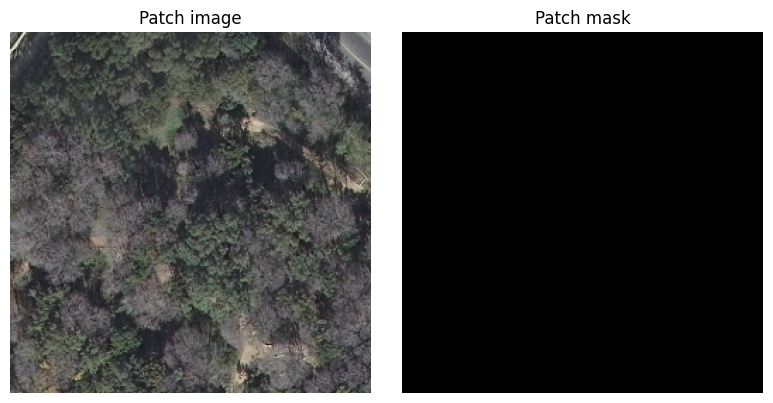

In [8]:
patch_image_files = sorted(PATCH_IMAGES_DIR.glob("*.png"))
patch_mask_files = sorted(PATCH_MASKS_DIR.glob("*.png"))

print(f"Patch images : {len(patch_image_files)}")
print(f"Patch masks  : {len(patch_mask_files)}")
print(f"Counts match : {len(patch_image_files) == len(patch_mask_files)}")

sample_patch = patch_image_files[0]
sample_mask = PATCH_MASKS_DIR / sample_patch.name

img_p = np.array(Image.open(sample_patch))
msk_p = np.array(Image.open(sample_mask))

print(f"Sample      : {sample_patch.name}")
print(f"Image shape : {img_p.shape}")
print(f"Mask shape  : {msk_p.shape} | values={np.unique(msk_p)}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_p)
axes[0].set_title("Patch image")
axes[1].imshow(msk_p, cmap="gray")
axes[1].set_title("Patch mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


### 3.5 Patching summary

- Patch size 256 × 256 with stride 256 (non-overlapping full windows only)
- Source: 180 paired train tiles; leftover edge strips smaller than 256 px skipped
- Output: `data/processed/patches/images` and `.../masks` (PNG, lossless)
- Result: 64,980 image patches and 64,980 mask patches


## 4. Spatial train/evaluation split

Separate patches into train and evaluation sets so the model is scored on geography it did not train on.

### 4.1 Split rule

The split is by **city**, not by random patch. Randomly shuffling all 64,980 patches would let neighboring crops from the same tile (and the same city) appear in both sets, which leaks spatial information and overstates performance.

**Rule used here:** hold out **Vienna** for evaluation; train on Austin, Chicago, Kitsap, and Tyrol. Every patch whose filename starts with `vienna` goes to evaluation; all other cities stay in training. That blocks both overlapping-neighbor leakage and geographic bleed across the held-out city.


### 4.2 Assign patches to train / eval

Label each saved patch by city from its filename and send Vienna patches to evaluation; the rest go to training.


In [9]:
EVAL_CITY = "vienna"

def tile_stem_from_patch(path: Path) -> str:
    # austin1_r0_c0.png -> austin1
    return path.stem.split("_r")[0]

patch_image_files = sorted(PATCH_IMAGES_DIR.glob("*.png"))

train_patches = []
eval_patches = []

for path in patch_image_files:
    city = city_from_stem(tile_stem_from_patch(path))
    if city == EVAL_CITY:
        eval_patches.append(path)
    else:
        train_patches.append(path)

print(f"Eval city     : {EVAL_CITY}")
print(f"Train patches : {len(train_patches)}")
print(f"Eval patches  : {len(eval_patches)}")
print(f"Total         : {len(train_patches) + len(eval_patches)} / {len(patch_image_files)}")


Eval city     : vienna
Train patches : 51984
Eval patches  : 12996
Total         : 64980 / 64980


### 4.3 Check the split

Confirm patch counts, list cities and tiles in each set, and verify Vienna does not appear in training.


In [10]:
def cities_in(paths):
    return sorted({city_from_stem(tile_stem_from_patch(p)) for p in paths})

def tiles_in(paths):
    return sorted({tile_stem_from_patch(p) for p in paths})

train_cities = cities_in(train_patches)
eval_cities = cities_in(eval_patches)
train_tiles = tiles_in(train_patches)
eval_tiles = tiles_in(eval_patches)
city_overlap = sorted(set(train_cities) & set(eval_cities))
tile_overlap = sorted(set(train_tiles) & set(eval_tiles))

print(f"Train patches : {len(train_patches)}")
print(f"Eval patches  : {len(eval_patches)}")
print(f"Train cities  : {train_cities}")
print(f"Eval cities   : {eval_cities}")
print(f"Train tiles   : {len(train_tiles)}")
print(f"Eval tiles    : {len(eval_tiles)}")
print(f"City overlap  : {city_overlap if city_overlap else 'none'}")
print(f"Tile overlap  : {tile_overlap if tile_overlap else 'none'}")
print(f"Vienna only in eval: {eval_cities == [EVAL_CITY] and EVAL_CITY not in train_cities}")


Train patches : 51984
Eval patches  : 12996
Train cities  : ['austin', 'chicago', 'kitsap', 'tyrolw']
Eval cities   : ['vienna']
Train tiles   : 144
Eval tiles    : 36
City overlap  : none
Tile overlap  : none
Vienna only in eval: True


### 4.4 Split summary

- Rule: city hold-out , evaluation city is Vienna; train on Austin, Chicago, Kitsap, and Tyrol
- Blocks neighboring-patch leakage and geographic bleed into the held-out city
- Train patches: 51,984 (144 tiles across 4 cities)
- Eval patches: 12,996 (36 Vienna tiles)
- Checks: no city overlap and no tile overlap between train and eval


## 5. Transforms and DataLoaders

Turn the train and eval patch lists into batched image/mask tensors for training.

### 5.1 Dataset class

Each item is one patch image and its matching mask (same filename under `patches/masks`).


In [11]:
class PatchSegDataset(Dataset):
    """Aerial patch + building mask pairs for segmentation."""

    def __init__(self, image_paths, mask_dir: Path, transform=None):
        self.image_paths = list(image_paths)
        self.mask_dir = Path(mask_dir)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_dir / img_path.name

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))
        if mask.ndim == 3:
            mask = mask[..., 0]

        # 255 = building → class 1; everything else → class 0
        mask = (mask == 255).astype(np.uint8)

        if self.transform is not None:
            image, mask = self.transform(image, mask)
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask.astype(np.int64))

        return image, mask

print(f"Dataset class ready | example size check: train={len(train_patches)}, eval={len(eval_patches)}")


Dataset class ready | example size check: train=51984, eval=12996


### 5.2 Transforms

Train patches get light geometric augmentations; the same flip/rotation is applied to the mask so labels stay aligned. Eval only converts to tensors. No random changes.


In [12]:
class JointTransform:
    """Apply the same geometric ops to image and mask, then convert to tensors."""

    def __init__(self, augment: bool = False):
        self.augment = augment

    def __call__(self, image: np.ndarray, mask: np.ndarray):
        if self.augment:
            if random.random() < 0.5:
                image = np.ascontiguousarray(np.flip(image, axis=1))
                mask = np.ascontiguousarray(np.flip(mask, axis=1))
            if random.random() < 0.5:
                image = np.ascontiguousarray(np.flip(image, axis=0))
                mask = np.ascontiguousarray(np.flip(mask, axis=0))
            k = random.randint(0, 3)
            if k:
                image = np.ascontiguousarray(np.rot90(image, k, axes=(0, 1)))
                mask = np.ascontiguousarray(np.rot90(mask, k, axes=(0, 1)))

        image_t = torch.from_numpy(image.copy()).permute(2, 0, 1).float() / 255.0
        mask_t = torch.from_numpy(mask.copy().astype(np.int64))
        return image_t, mask_t


train_transform = JointTransform(augment=True)
eval_transform = JointTransform(augment=False)

print("Transforms ready: train (flip/rot90) | eval (tensor only)")


Transforms ready: train (flip/rot90) | eval (tensor only)


### 5.3 Build DataLoaders

Wrap the train and eval patch lists in `PatchSegDataset`, then batch them. Training shuffles; evaluation does not.


In [13]:
train_dataset = PatchSegDataset(train_patches, PATCH_MASKS_DIR, transform=train_transform)
eval_dataset = PatchSegDataset(eval_patches, PATCH_MASKS_DIR, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)
eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"Train set : {len(train_dataset)} patches | batches≈{len(train_loader)}")
print(f"Eval set  : {len(eval_dataset)} patches | batches≈{len(eval_loader)}")
print(f"Batch size: {BATCH_SIZE}")


Train set : 51984 patches | batches≈12996
Eval set  : 12996 patches | batches≈3249
Batch size: 4


### 5.4 Check a batch

Pull one batch from each loader and confirm image and mask shapes.


In [14]:
images_b, masks_b = next(iter(train_loader))
print(f"Train batch | images {tuple(images_b.shape)} | masks {tuple(masks_b.shape)}")
print(
    f"Train batch | image range [{images_b.min().item():.3f}, {images_b.max().item():.3f}] "
    f"| mask values {masks_b.unique().tolist()}"
)

images_e, masks_e = next(iter(eval_loader))
print(f"Eval batch  | images {tuple(images_e.shape)} | masks {tuple(masks_e.shape)}")
print(
    f"Eval batch  | image range [{images_e.min().item():.3f}, {images_e.max().item():.3f}] "
    f"| mask values {masks_e.unique().tolist()}"
)


Train batch | images (4, 3, 256, 256) | masks (4, 256, 256)
Train batch | image range [0.000, 1.000] | mask values [0, 1]
Eval batch  | images (4, 3, 256, 256) | masks (4, 256, 256)
Eval batch  | image range [0.102, 1.000] | mask values [0, 1]


### 5.5 DataLoader summary

- `PatchSegDataset` loads each patch with its matching mask and maps building pixels to class 1
- Train transform: random flips and 90° rotations on image and mask together; eval has no random ops
- Images scaled to [0, 1] as CHW float tensors; masks are HxW class ids
- Train loader shuffles (51,984 patches); eval loader does not (12,996 Vienna patches)
- Batch check: images `(B, 3, 256, 256)`, masks `(B, 256, 256)` with `B = 4`


## 6. Model

Define a segmentation network that predicts a building mask for each 256 x 256 patch.

### 6.1 Architecture choice

The target is a full HxW mask, so the model must predict every pixel, not one score for the whole patch.

This project uses a **U-Net-style encoder-decoder**:

- The **encoder** downsamples the patch and builds richer features
- The **decoder** upsamples back to 256 x 256 so every pixel gets a prediction
- **Skip connections** pass fine detail from encoder to decoder, which helps building edges

Output is **one logit channel** per pixel (0 = background, 1 = building). At inference: sigmoid, then threshold 0.5 for the hard mask. Training uses BCE-with-logits and Dice so sigmoid stays inside the loss.


### 6.2 Build the U-Net

Implement the U-Net in PyTorch: four encoder stages, a bottleneck, four decoder stages with skips, and a 1×1 head that outputs one logit channel. Base width is 32 channels (then 64, 128, 256) to keep the model light on this machine.


In [15]:
class DoubleConv(nn.Module):
    """Two Conv-BN-ReLU blocks used in every U-Net stage."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        # 3×3 conv keeps spatial size; BN + ReLU after each conv
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """Encoder–decoder U-Net with skip connections; outputs 1 logit channel."""

    def __init__(self, in_ch: int = 3, out_ch: int = 1, base_ch: int = 32):
        super().__init__()
        # channel widths grow as resolution shrinks: 32, 64, 128, 256
        c1, c2, c3, c4 = base_ch, base_ch * 2, base_ch * 4, base_ch * 8

        # encoder: extract features while downsampling
        self.enc1 = DoubleConv(in_ch, c1)
        self.enc2 = DoubleConv(c1, c2)
        self.enc3 = DoubleConv(c2, c3)
        self.enc4 = DoubleConv(c3, c4)
        self.pool = nn.MaxPool2d(2)  # halves H and W

        # deepest representation before we start upsampling
        self.bottleneck = DoubleConv(c4, c4 * 2)

        # decoder: upsample, then fuse with matching encoder skip
        self.up4 = nn.ConvTranspose2d(c4 * 2, c4, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(c4 * 2, c4)  # *2 because of concat with skip
        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(c3 * 2, c3)
        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(c2 * 2, c2)
        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(c1 * 2, c1)

        # one logit per pixel (building vs background)
        self.head = nn.Conv2d(c1, out_ch, kernel_size=1)

    def forward(self, x):
        # --- encode ---
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        # --- decode (cat brings fine detail back from the encoder) ---
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.head(d1)


model = UNet(in_ch=3, out_ch=1, base_ch=32).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net ready | device={DEVICE} | trainable params={n_params:,}")


U-Net ready | device=cpu | trainable params=7,763,041


### 6.3 Forward check

Run one train batch through the model and confirm the output is one logit map per image at the same spatial size as the input.


In [16]:
images_b, masks_b = next(iter(train_loader))
images_b = images_b.to(DEVICE)

model.eval()
with torch.no_grad():
    logits = model(images_b)

print(f"Input  | images {tuple(images_b.shape)} | masks {tuple(masks_b.shape)}")
print(f"Output | logits {tuple(logits.shape)}")
print(f"Logit range [{logits.min().item():.3f}, {logits.max().item():.3f}]")


Input  | images (4, 3, 256, 256) | masks (4, 256, 256)
Output | logits (4, 1, 256, 256)
Logit range [0.096, 0.109]


### 6.4 Model summary

- Architecture: from-scratch U-Net (encoder, bottleneck, decoder with skips)
- Building block: `DoubleConv` (Conv-BN-ReLU × 2) at each stage
- Base width 32 channels (32, 64, 128, 256); ~7.8M trainable parameters
- Input: `(B, 3, 256, 256)` RGB patch
- Output: `(B, 1, 256, 256)` logits (one channel per pixel; sigmoid / threshold later)
- Forward check on a train batch confirmed matching spatial size


## 7. Loss

Define how training scores a predicted mask against the ground-truth mask.

### 7.1 Why this loss

Most pixels in an aerial patch are background. A model that always predicts "no building" can look accurate and still miss the roofs. Boundaries matter too. Blurry edges make a weak footprint mask.

So the training loss needs two jobs:

- **Per-pixel classification**: push each pixel toward 0 (background) or 1 (building)
- **Region overlap**: reward masks that cover the true building area, not only easy background pixels

That points to a **combined loss**: BCE-with-logits (pixel-wise) plus Dice (overlap). BCE alone under-weights rare building pixels; Dice alone can be unstable early on. Together they handle imbalance and footprint shape better than plain accuracy.


### 7.2 BCE-with-logits

Binary cross-entropy scores each pixel as building or background. Use **BCE-with-logits** so the loss takes the U-Net raw logits and applies sigmoid internally, which is more stable than sigmoid first, then BCE.

Masks stay `{0, 1}` and must be float tensors matching the logit shape `(B, 1, H, W)`.


In [17]:
# Per-pixel binary loss on logits (sigmoid is inside this loss)
bce_loss_fn = nn.BCEWithLogitsLoss()
print("BCE-with-logits ready")

BCE-with-logits ready


### 7.3 Dice loss

Dice measures overlap between the predicted building region and the true mask. It cares more about the building pixels than the huge background, so it helps with class imbalance and pushes clearer footprints.

Use a **soft Dice** on probabilities: sigmoid the logits, then compare to the float mask. A small smooth term keeps the score stable when a patch has almost no buildings.

In [18]:
def dice_loss_fn(logits, targets, smooth: float = 1.0):
    """Soft Dice loss from logits. targets are float {0, 1} with shape matching probs."""
    probs = torch.sigmoid(logits)
    probs = probs.reshape(-1)
    targets = targets.reshape(-1)

    intersection = (probs * targets).sum()
    dice = (2.0 * intersection + smooth) / (probs.sum() + targets.sum() + smooth)
    return 1.0 - dice


print("Dice loss ready")


Dice loss ready


### 7.4 Combined loss

Training uses both terms together: BCE for per-pixel correctness, Dice for building-region overlap. Equal weight to start.

`L = BCE-with-logits + Dice`

In [19]:
def combined_loss(logits, masks):
    """BCE-with-logits + soft Dice. masks are (B, H, W) class ids {0, 1}."""
    # match logit shape (B, 1, H, W) and use float targets for BCE / Dice
    targets = masks.unsqueeze(1).float()
    bce = bce_loss_fn(logits, targets)
    dice = dice_loss_fn(logits, targets)
    return bce + dice, bce.detach(), dice.detach()

print("Combined loss ready | L = BCE + Dice")

Combined loss ready | L = BCE + Dice


### 7.5 Check the loss

Just a check that the model and loss plug together before real training. One train batch through both; the loss should be a real number (not NaN).


In [20]:
images_b, masks_b = next(iter(train_loader))
images_b = images_b.to(DEVICE)
masks_b = masks_b.to(DEVICE)

model.eval()
with torch.no_grad():
    logits = model(images_b)
    loss, bce, dice = combined_loss(logits, masks_b)

print(f"Logits {tuple(logits.shape)} | masks {tuple(masks_b.shape)}")
print(f"Loss {loss.item():.4f} | BCE {bce.item():.4f} | Dice {dice.item():.4f}")


Logits (4, 1, 256, 256) | masks (4, 256, 256)
Loss 1.5097 | BCE 0.7312 | Dice 0.7785


### 7.6 Metrics

For evaluation and reporting, turn logits into a hard mask with sigmoid and threshold 0.5, then score **IoU** and **Dice**. Pixel accuracy is weak alone here because background dominates, so it stays secondary.


In [21]:
def predict_mask(logits, threshold: float = 0.5):
    """Logits - hard building mask {0, 1}."""
    return (torch.sigmoid(logits) > threshold).float()


def batch_iou_dice(logits, masks, threshold: float = 0.5, eps: float = 1e-7):
    """Mean IoU and Dice over a batch. masks are (B, H, W) with {0, 1}."""
    preds = predict_mask(logits, threshold).squeeze(1)  # (B, H, W)
    targets = masks.float()

    preds_flat = preds.reshape(preds.size(0), -1)
    targets_flat = targets.reshape(targets.size(0), -1)

    intersection = (preds_flat * targets_flat).sum(dim=1)
    pred_sum = preds_flat.sum(dim=1)
    target_sum = targets_flat.sum(dim=1)
    union = pred_sum + target_sum - intersection

    iou = ((intersection + eps) / (union + eps)).mean()
    dice = ((2.0 * intersection + eps) / (pred_sum + target_sum + eps)).mean()
    return iou, dice


# same pre-training batch as the loss check
iou, dice = batch_iou_dice(logits, masks_b)
print(f"Batch metrics | IoU {iou.item():.4f} | Dice {dice.item():.4f}")
print("Metric helpers ready")


Batch metrics | IoU 0.1403 | Dice 0.2221
Metric helpers ready


### 7.7 Loss summary

- Train loss: BCE-with-logits + soft Dice (equal weight)
- BCE handles per-pixel labels; Dice pushes building-region overlap
- Eval metrics: IoU and Dice on the thresholded mask
- Inference: sigmoid, then 0.5 threshold for a binary footprint (no BCE needed)


## 8. Training and validation

Train the U-Net on the train patches and score Vienna each epoch.

### 8.1 Training setup

Adam optimizer, history logs for loss/IoU/Dice, and a checkpoint path for the best eval IoU weights.


In [22]:
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "unet_best.pth"

optimizer = optim.Adam(model.parameters(), lr=LR)

history = {
    "train_loss": [],
    "eval_loss": [],
    "eval_iou": [],
    "eval_dice": [],
}
best_eval_iou = -1.0  # any real IoU will beat this on the first save

print(f"Optimizer   : Adam | lr={LR}")
print(f"Epochs      : {EPOCHS}")
print(f"Checkpoint  : {CHECKPOINT_PATH}")


Optimizer   : Adam | lr=0.001
Epochs      : 10
Checkpoint  : C:\Users\Ibuchi Basil\data-science\bike-share\footprint-segmentation\checkpoints\unet_best.pth


### 8.2 Train one epoch

One full pass over `train_loader`: forward, combined loss, backward, optimizer step. Returns the mean train loss.

In [23]:
def train_one_epoch(model, loader, optimizer, device):
    """One pass over the training set. Returns mean combined loss."""
    model.train()
    running_loss = 0.0

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss, _, _ = combined_loss(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / max(len(loader), 1)


print("train_one_epoch ready")


train_one_epoch ready


### 8.3 Evaluate one epoch

Score the eval loader with no gradient updates. Returns mean loss, IoU, and Dice.

In [24]:
def evaluate_one_epoch(model, loader, device):
    """One pass over the eval set. Returns mean loss, IoU, and Dice."""
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Eval", leave=False):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss, _, _ = combined_loss(logits, masks)
            iou, dice = batch_iou_dice(logits, masks)

            running_loss += loss.item()
            running_iou += iou.item()
            running_dice += dice.item()

    n = max(len(loader), 1)
    return running_loss / n, running_iou / n, running_dice / n


print("evaluate_one_epoch ready")

evaluate_one_epoch ready


### 8.4 Full train loop

For each epoch: train, evaluate on Vienna, log metrics, and save weights when eval IoU improves.

This cell is **not run on this machine**. The loop is kept below for reference and disabled with `RUN_TRAINING = False`. Training was done on a machine with GPU support (see 8.5).


In [25]:
# Full train loop kept for reference. Disabled on this machine.
# Set RUN_TRAINING = True to train locally or on another machine.
RUN_TRAINING = False

if RUN_TRAINING:
    print(f"Training on {DEVICE} | batch={BATCH_SIZE} | lr={LR} | epochs={EPOCHS}")

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        eval_loss, eval_iou, eval_dice = evaluate_one_epoch(model, eval_loader, DEVICE)

        history["train_loss"].append(train_loss)
        history["eval_loss"].append(eval_loss)
        history["eval_iou"].append(eval_iou)
        history["eval_dice"].append(eval_dice)

        # keep the weights with the best Vienna IoU so far
        if eval_iou > best_eval_iou:
            best_eval_iou = eval_iou
            torch.save(
                {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "best_eval_iou": best_eval_iou,
                    "history": history,
                },
                CHECKPOINT_PATH,
            )
            saved = "saved"
        else:
            saved = "no save"

        elapsed = time.time() - t0
        print(
            f"Epoch {epoch}/{EPOCHS} | "
            f"train_loss {train_loss:.4f} | eval_loss {eval_loss:.4f} | "
            f"IoU {eval_iou:.4f} | Dice {eval_dice:.4f} | "
            f"{elapsed:.1f}s | {saved}"
        )

    print(f"\nDone. Best eval IoU={best_eval_iou:.4f} | checkpoint={CHECKPOINT_PATH}")
else:
    print("Train loop skipped on this machine | RUN_TRAINING=False")
    print(f"Expected checkpoint path: {CHECKPOINT_PATH}")


Train loop skipped on this machine | RUN_TRAINING=False
Expected checkpoint path: C:\Users\Ibuchi Basil\data-science\bike-share\footprint-segmentation\checkpoints\unet_best.pth


### 8.5 External training note

This machine is CPU-only, so a full Inria training run is not practical here.

The U-Net was trained on an Apple MacBook Pro M1 using PyTorch MPS (GPU): batch size 4, learning rate 0.001, 10 epochs. The best checkpoint (eval IoU) was copied into `checkpoints/unet_best.pth` for this notebook. The next step loads those weights and continues with evaluation and analysis.


### 8.6 Load trained checkpoint

Load the trained weights into the U-Net on this machine. Confirm the file exists, restore `model_state`, and pull back history / best IoU if they were saved in the checkpoint.


In [26]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}\n"
        "Copy unet_best.pth from the training machine into checkpoints/ first."
    )

# map_location lets MPS-trained weights load on CPU (or CUDA) here
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.to(DEVICE)
model.eval()

if "history" in checkpoint:
    history = checkpoint["history"]
if "best_eval_iou" in checkpoint:
    best_eval_iou = checkpoint["best_eval_iou"]

print(f"Loaded checkpoint: {CHECKPOINT_PATH}")
print(f"Saved at epoch   : {checkpoint.get('epoch', '?')}")
print(f"Best eval IoU    : {best_eval_iou}")
print(f"Device           : {DEVICE}")

Loaded checkpoint: C:\Users\Ibuchi Basil\data-science\bike-share\footprint-segmentation\checkpoints\unet_best.pth
Saved at epoch   : 8
Best eval IoU    : 0.6267119588636187
Device           : cpu


### 8.7 Training summary

- Train machine: Apple MacBook Pro M1 (PyTorch MPS)
- Settings: batch size 4, lr 0.001, 10 epochs, Adam, loss = BCE + Dice
- Eval city: Vienna (city hold-out)
- Best checkpoint: epoch 8 | eval IoU 0.6267 | eval Dice 0.7307
- Train loss fell across epochs (0.78 to 0.38); eval IoU varied and peaked at epoch 8
- Checkpoint path: `checkpoints/unet_best.pth` (loaded in 8.6)


## 9. Curves and quantitative results

Plot the training history and report the Vienna scores from the training run.

### 9.1 Training curves

Train loss, eval loss, IoU, and Dice across the 10 epochs. Use `history` from the checkpoint when it has all epochs; otherwise use the recorded training log.


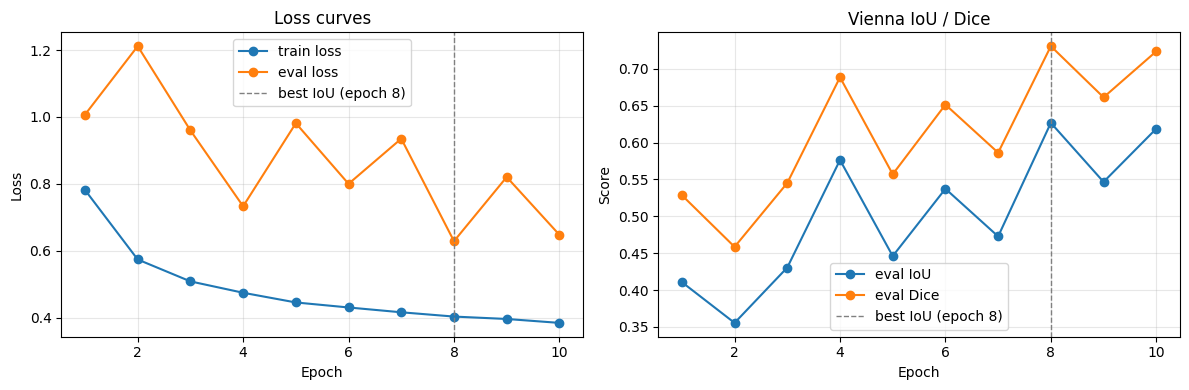

Plotted 10 epochs | best eval IoU at epoch 8 (0.6267)


In [27]:
# Recorded 10-epoch training log. Used if checkpoint history is short or missing.
run_history = {
    "train_loss": [0.7814, 0.5735, 0.5080, 0.4740, 0.4450, 0.4300, 0.4156, 0.4028, 0.3956, 0.3839],
    "eval_loss": [1.0067, 1.2115, 0.9596, 0.7326, 0.9811, 0.7998, 0.9348, 0.6283, 0.8201, 0.6473],
    "eval_iou": [0.4107, 0.3554, 0.4305, 0.5763, 0.4460, 0.5373, 0.4727, 0.6267, 0.5466, 0.6188],
    "eval_dice": [0.5286, 0.4585, 0.5452, 0.6885, 0.5570, 0.6514, 0.5862, 0.7307, 0.6613, 0.7237],
}

plot_history = run_history
if (
    isinstance(history, dict)
    and len(history.get("train_loss", [])) >= 10
):
    plot_history = history

epochs = list(range(1, len(plot_history["train_loss"]) + 1))
best_epoch = int(np.argmax(plot_history["eval_iou"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(epochs, plot_history["train_loss"], marker="o", label="train loss")
ax.plot(epochs, plot_history["eval_loss"], marker="o", label="eval loss")
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"best IoU (epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss curves")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs, plot_history["eval_iou"], marker="o", label="eval IoU")
ax.plot(epochs, plot_history["eval_dice"], marker="o", label="eval Dice")
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"best IoU (epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Vienna IoU / Dice")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Plotted {len(epochs)} epochs | best eval IoU at epoch {best_epoch} "
      f"({plot_history['eval_iou'][best_epoch - 1]:.4f})")


### 9.2 Results

Vienna metrics come from the training run (same split and checkpoint). A full re-eval on this machine is skipped because it is too slow on CPU.

| Epoch | Train loss | Eval loss | IoU | Dice | Checkpoint |
|------:|----------:|----------:|----:|-----:|:-----------|
| 1 | 0.7814 | 1.0067 | 0.4107 | 0.5286 | saved |
| 2 | 0.5735 | 1.2115 | 0.3554 | 0.4585 | |
| 3 | 0.5080 | 0.9596 | 0.4305 | 0.5452 | saved |
| 4 | 0.4740 | 0.7326 | 0.5763 | 0.6885 | saved |
| 5 | 0.4450 | 0.9811 | 0.4460 | 0.5570 | |
| 6 | 0.4300 | 0.7998 | 0.5373 | 0.6514 | |
| 7 | 0.4156 | 0.9348 | 0.4727 | 0.5862 | |
| 8 | 0.4028 | 0.6283 | **0.6267** | **0.7307** | saved (best) |
| 9 | 0.3956 | 0.8201 | 0.5466 | 0.6613 | |
| 10 | 0.3839 | 0.6473 | 0.6188 | 0.7237 | |

Train loss fell across all 10 epochs. Eval IoU bounced (dip at epoch 2, another dip around 5 to 7) and peaked at **epoch 8** (IoU 0.6267, Dice 0.7307). Epoch 10 was close but did not beat that best, so the saved weights stay on epoch 8.


In [28]:
# Reported Vienna scores from the training run (best checkpoint = epoch 8)
best_i = int(np.argmax(run_history["eval_iou"]))
final_epoch = best_i + 1
final_loss = run_history["eval_loss"][best_i]
final_iou = run_history["eval_iou"][best_i]
final_dice = run_history["eval_dice"][best_i]

print(
    f"Reported best | epoch {final_epoch} | "
    f"loss {final_loss:.4f} | IoU {final_iou:.4f} | Dice {final_dice:.4f}"
)


Reported best | epoch 8 | loss 0.6283 | IoU 0.6267 | Dice 0.7307


### 9.3 Results summary

- Curves: train loss down; eval IoU / Dice peak at epoch 8
- Best Vienna score: IoU 0.6267 | Dice 0.7307 | eval loss 0.6283
- Checkpoint used for later visuals: `checkpoints/unet_best.pth` (epoch 8)


## 10. Visual error analysis

Check the best checkpoint on Vienna patches: aerial image, ground-truth mask, and prediction side by side.

### 10.1 Pick examples

Score a slice of the Vienna eval set and keep five patches that contain both buildings and background. Targets are IoU near 1.0, 0.75, 0.5, 0.25, and 0.0 (closest available match for each).


In [29]:
# Scan Vienna patches; pick 5 with buildings + background near target IoUs
N_SCAN = 128
MIN_BUILDING_PIXELS = 500
MIN_BACKGROUND_PIXELS = 500
TARGET_IOUS = [1.0, 0.75, 0.5, 0.25, 0.0]

records = []  # (iou, building_px, background_px, image, mask, pred)

model.eval()
seen = 0
with torch.no_grad():
    for images, masks in eval_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        logits = model(images)
        preds = predict_mask(logits).squeeze(1)

        for i in range(images.size(0)):
            pred = preds[i]
            target = masks[i].float()
            building_px = float(target.sum().item())
            background_px = float((1.0 - target).sum().item())
            inter = (pred * target).sum()
            union = pred.sum() + target.sum() - inter
            iou = ((inter + 1e-7) / (union + 1e-7)).item()

            records.append(
                (
                    iou,
                    building_px,
                    background_px,
                    images[i].detach().cpu(),
                    target.detach().cpu(),
                    pred.detach().cpu(),
                )
            )
            seen += 1
            if seen >= N_SCAN:
                break
        if seen >= N_SCAN:
            break

# both classes present in the GT mask
mixed = [
    r for r in records
    if r[1] >= MIN_BUILDING_PIXELS and r[2] >= MIN_BACKGROUND_PIXELS
]
pool = mixed if len(mixed) >= len(TARGET_IOUS) else records

vis_examples = []
used = set()
for target in TARGET_IOUS:
    best_j = None
    best_dist = None
    for j, r in enumerate(pool):
        if j in used:
            continue
        dist = abs(r[0] - target)
        if best_dist is None or dist < best_dist:
            best_dist = dist
            best_j = j
    if best_j is None:
        break
    used.add(best_j)
    r = pool[best_j]
    vis_examples.append((r[0], r[3], r[4], r[5]))

print(f"Scanned {len(records)} | mixed building+background: {len(mixed)}")
print("Selected IoUs:", [round(r[0], 4) for r in vis_examples])
print("Targets      :", TARGET_IOUS)


Scanned 128 | mixed building+background: 117
Selected IoUs: [0.9138, 0.753, 0.4985, 0.1654, 0.0]
Targets      : [1.0, 0.75, 0.5, 0.25, 0.0]


### 10.2 Prediction panels

For each selected patch: aerial image, ground-truth mask, and predicted mask (sigmoid, threshold 0.5).

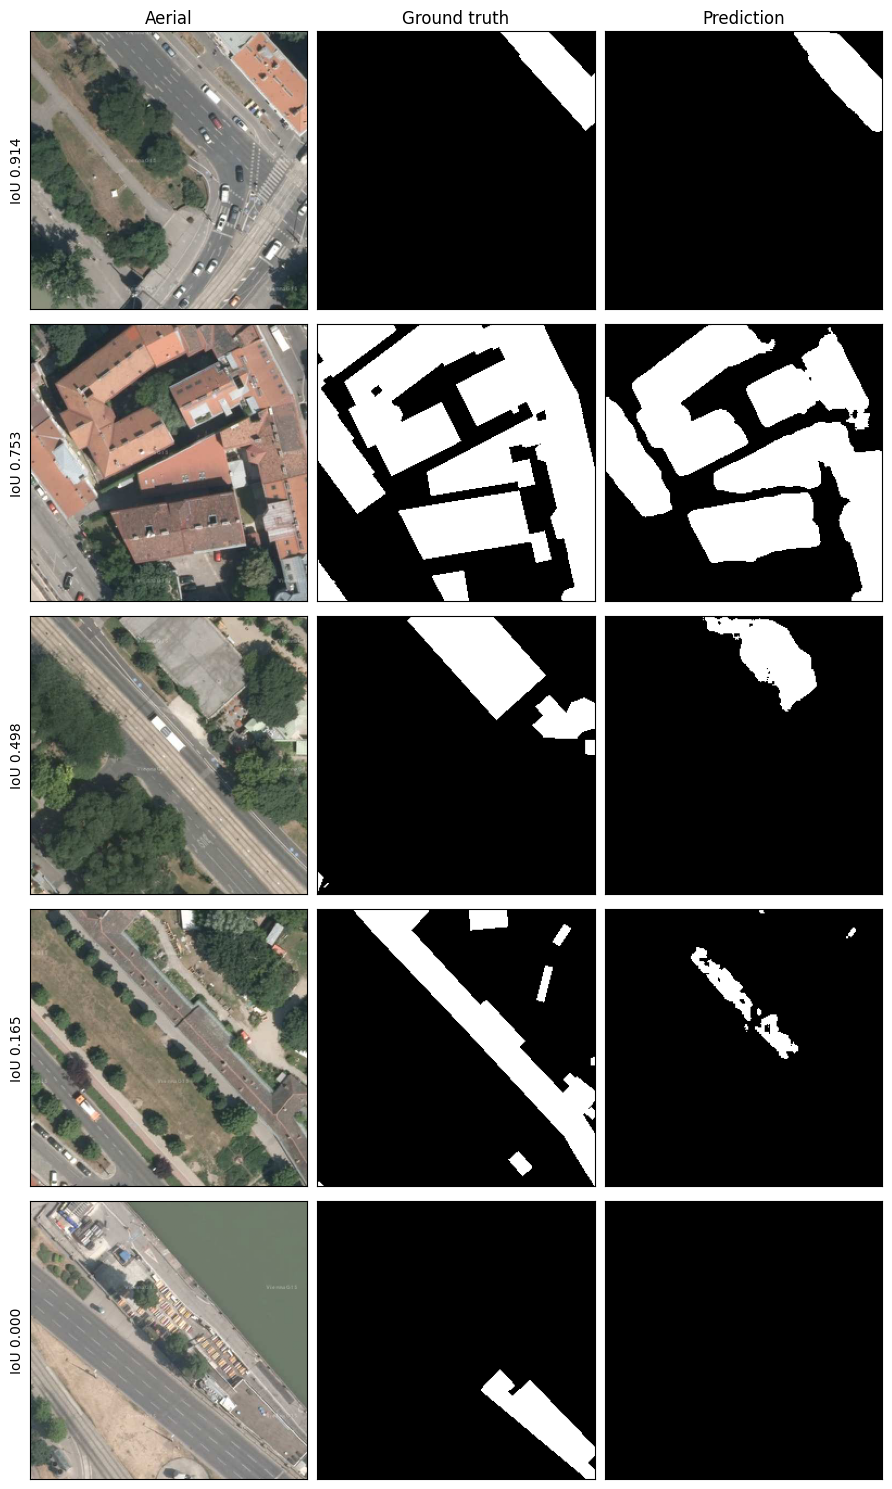

In [30]:
n = len(vis_examples)
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
if n == 1:
    axes = np.expand_dims(axes, axis=0)

col_titles = ["Aerial", "Ground truth", "Prediction"]
for row, (iou, image_t, mask_t, pred_t) in enumerate(vis_examples):
    # CHW float [0,1] -> HWC for display
    rgb = image_t.permute(1, 2, 0).numpy()
    gt = mask_t.numpy()
    pred = pred_t.numpy()

    panels = [rgb, gt, pred]
    cmaps = [None, "gray", "gray"]
    for col, (panel, cmap) in enumerate(zip(panels, cmaps)):
        ax = axes[row, col]
        if cmap is None:
            ax.imshow(panel)
        else:
            ax.imshow(panel, cmap=cmap, vmin=0, vmax=1)
        if row == 0:
            ax.set_title(col_titles[col])
        ax.set_xticks([])
        ax.set_yticks([])
    axes[row, 0].set_ylabel(f"IoU {iou:.3f}", fontsize=10)

plt.tight_layout()
plt.show()


### 10.3 What works / what fails

Across the five Vienna panels, quality tracks IoU as expected:

- **IoU near 1.0:** prediction lines up almost perfectly with the ground truth.
- **IoU ~0.75:** still separates buildings from background clearly; most of the footprint is right.
- **IoU ~0.50:** gets a number of buildings, but misses or smears others.
- **IoU ~0.17:** poorer overall, yet still marks some white (building) areas.
- **IoU ~0:** poorest case; prediction stays all background and does not identify any building pixels.

So the model is reliable on clearer patches and degrades as the task gets harder, down to total misses on the weakest examples.


### 10.4 Visual analysis summary

- Five Vienna panels spanning high to low IoU (buildings + background in each aerial patch)
- High IoU: prediction matches GT closely
- Mid IoU: partial building recovery
- Low / zero IoU: weak or no building detection (all-background pred at IoU 0)


## 11. Optional hybrid CNN-ViT

Skipped. The from-scratch U-Net already covers the full pipeline needed here.


## 12. Conclusions

This notebook ran a binary building-footprint segmentation pipeline on the Inria aerial dataset.

**Data and split**  
Tiles were cut into 256 x 256 non-overlapping patches. Train cities: Austin, Chicago, Kitsap, Tyrol. **Vienna** was held out so the score is not inflated by spatial leakage.

**Model and loss**  
A from-scratch U-Net predicts one logit per pixel. Loss was **BCE-with-logits + soft Dice** for per-pixel labels and building overlap under class imbalance.

**Results**  
Best checkpoint: epoch 8 of 10. Vienna **IoU 0.6267**, **Dice 0.7307**. Train loss fell across epochs; eval IoU bounced and peaked at epoch 8.

**Visual checks**  
Panels (aerial | ground truth | prediction) follow the IoU ladder: almost perfect at high IoU, partial buildings in the middle, all-background misses at IoU near 0. Weakest cases are small or unclear building regions.

**Takeaway**  
City hold-out, a compact U-Net, and BCE+Dice gave a usable footprint model and made the failure modes easy to see. More epochs, a stronger encoder, or extra focus on small buildings could help later; that was left out of scope here.
